# **Paradigmas y Programación para Ciencia de Datos**

## **Proyecto - Películas**

In [ ]:
# Bibliotecas necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Objetivos

* Predecir el éxito / fracaso de una película utilizando varios modelos para el análisis de datos.
* Recomendar películas similares dada una película utilizando varios modelos para el análisis de datos.

## Análisis Exploratorio de los Datos

### **Datos utilizados**

**Utilizamos** la información de dos bases de datos distintas, ambas recolectadas de kaggle.com.

1. El conjunto de datos: '25k IMDb Movie Dataset', que contiene las siguientes variables:

* Título de película
* Duración total
* Rating
* Géneros
* Resumen
* Palabras clave
* Top 5 nombres del cast
* Nombre del escritor
* Año de lanzamiento
* url de IMDb

Link del dataset: https://www.kaggle.com/datasets/utsh0dey/25k-movie-dataset


2. El conjunto de datos '🎬 Movies Metadata Cleaned Dataset (1900–2025)', que contiene las siguientes variables:

* id
* Título
* Es adulta
* Lenguaje original
* País de Origen
* Fecha de lanzamiento
* Géneros
* Nombre de la compañía de producción
* Presupuesto
* Ganancia
* Duración
* Popularidad
* Rating Promedio
* Número de votos

Link del dataset: https://www.kaggle.com/datasets/mustafasayed1181/movies-metadata-cleaned-dataset-19002025

### **Información de los datos**

**1. 25k IMDb Movie Dataset**

In [ ]:
# Importamos el dataset
df1 = pd.read_csv('movies_imdb.csv')

In [ ]:
# Visualización preliminar
display(df1.head(3))

,movie title,Run Time,Rating,User Rating,Generes,Overview,Plot Kyeword,Director,Top 5 Casts,Writer,year,path
0,Top Gun: Maverick,"$170,000,000 (estimated)",8.6,187K,"['Action', 'Drama']",After more than thirty years of service as one...,"['fighter jet', 'sequel', 'u.s. navy', 'fighte...",Joseph Kosinski,"['Jack Epps Jr.', 'Peter Craig', 'Tom Cruise',...",Jim Cash,-2022,/title/tt1745960/
1,Jurassic World Dominion,2 hours 27 minutes,6,56K,"['Action', 'Adventure', 'Sci-Fi']",Four years after the destruction of Isla Nubla...,"['dinosaur', 'jurassic park', 'tyrannosaurus r...",Colin Trevorrow,"['Colin Trevorrow', 'Derek Connolly', 'Chris P...",Emily Carmichael,-2022,/title/tt8041270/
2,Top Gun,"$15,000,000 (estimated)",6.9,380K,"['Action', 'Drama']",As students at the United States Navy's elite ...,"['pilot', 'male camaraderie', 'u.s. navy', 'gr...",Tony Scott,"['Jack Epps Jr.', 'Ehud Yonay', 'Tom Cruise', ...",Jim Cash,-1986,/title/tt0092099/


In [ ]:
# Tamaño del conjunto de datos
print('Tamaño del conjunto de datos:',df1.shape)

Tamaño del conjunto de datos: (24402, 12)


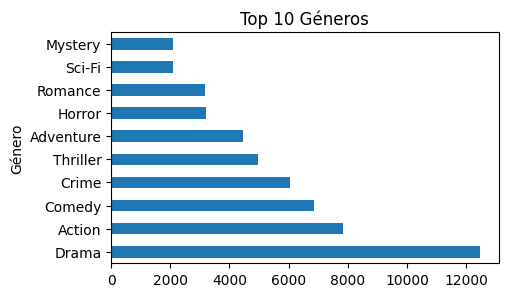

In [ ]:
# Top 10 géneros
genres = df1['Generes'].str.replace(r'[\[\]\']', '', regex=True).str.split(', ')
genres_exploded = genres.explode()
top_genres = genres_exploded.value_counts()

top_genres.head(10).plot(kind='barh', title='Top 10 Géneros', figsize=(5,3))
plt.ylabel("Género")
plt.show()

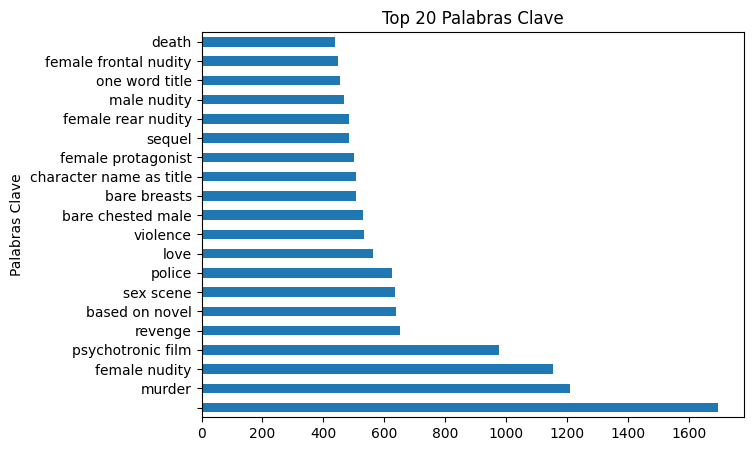

In [ ]:
# Top 30 palabras clave
keywords = df1['Plot Kyeword'].str.replace(r'[\[\]\']', '', regex=True).str.split(', ')
keywords_exploded = keywords.explode()
top_keywords = keywords_exploded.value_counts()

top_keywords.head(20).plot(kind='barh', title='Top 20 Palabras Clave', figsize=(7,5))
plt.ylabel('Palabras Clave')
plt.show()

In [ ]:
# Top 10 rating -> Escritor
cleaned_ratings = pd.to_numeric(df1['Rating'], errors='coerce')
temp_df = pd.DataFrame({'Writer': df1['Writer'], 'Rating': cleaned_ratings})
top_writers_rating = temp_df.groupby('Writer')['Rating'].mean().sort_values(ascending=False)
display(top_writers_rating.head(10))

,Rating
Writer,
Logan Kramer,9.9
Ross Holman,9.9
VV Vinayan,9.8
Mahivarman.cs,9.8
Bart Gavigan,9.7
Korean,9.7
Mahkamov Otabek,9.7
Cooper Bibaud,9.6
Brett Smith,9.5


In [ ]:
# Top 10 rating -> Géneros
temp_df = pd.DataFrame({'Generes': df1['Generes'], 'Rating': cleaned_ratings})
top_genres_rating = temp_df.groupby('Generes')['Rating'].mean().sort_values(ascending=False)
display(top_genres_rating.head(10))

,Rating
Generes,
"['Action', 'Adventure', 'Music']",9.9
['Musical'],8.7
"['Action', 'Family', 'Romance']",8.3
"['Drama', 'Fantasy', 'War']",8.2
"['Animation', 'Biography', 'Drama']",8.0
"['Drama', 'History', 'Musical']",7.9
"['Crime', 'Fantasy', 'Romance']",7.9
"['Action', 'Crime', 'Comedy']",7.9
"['Animation', 'Adventure', 'Music']",7.8


**2. 🎬 Movies Metadata Cleaned Dataset (1900–2025)**

In [ ]:
# Importamos el dataset
df2 = pd.read_csv('movies.csv')

In [ ]:
# Tamaño del conjunto de datos
print('Tamaño del conjunto de datos:',df2.shape)

Tamaño del conjunto de datos: (946460, 14)


In [ ]:
# Visualización preliminar
df2.head(3)

,id,title,adult,original_language,origin_country,release_date,genre_names,production_company_names,budget,revenue,runtime,popularity,vote_average,vote_count
0,195554,Panorama of Galveston Power House,False,en,['US'],1900-05-21,[],[],2426.703143,3322.065977,1,6.3707,4.0,4
1,105303,Explosion of a Motor Car,False,xx,['GB'],1900-07-01,['Comedy'],['Hepworth'],1486.884235,1605.985979,2,3.4255,6.1,55
2,195553,"Panorama of Orphans' Home, Galveston",False,en,['US'],1900-09-21,[],[],4686.762515,3456.639124,1,3.2375,4.0,5


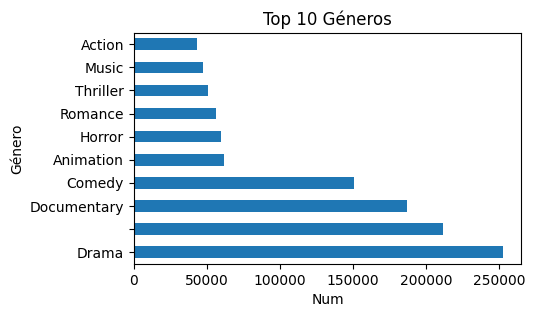

In [ ]:
# Top 10 géneros
genres = df2['genre_names'].str.replace(r'[\[\]\']', '', regex=True).str.split(', ')
genres_exploded = genres.explode()
top_genres = genres_exploded.value_counts().head(10)

top_genres.plot(kind='barh', title='Top 10 Géneros', figsize=(5,3))
plt.xlabel("Num")
plt.ylabel("Género")
plt.show()

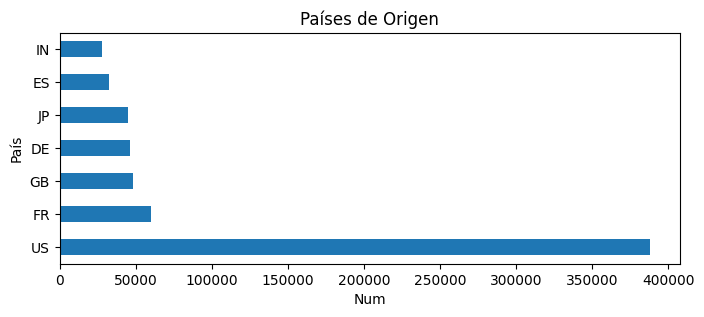

In [ ]:
# Top 7 países de origen
countries = df2['origin_country'].str.replace(r'[\[\]\']', '', regex=True).str.split(', ')
countries_exploded = countries.explode()
top_countries = countries_exploded.value_counts().head(7)

top_countries.plot(kind='barh', title='Países de Origen', figsize=(8,3))
plt.xlabel("Num")
plt.ylabel("País")
plt.show()

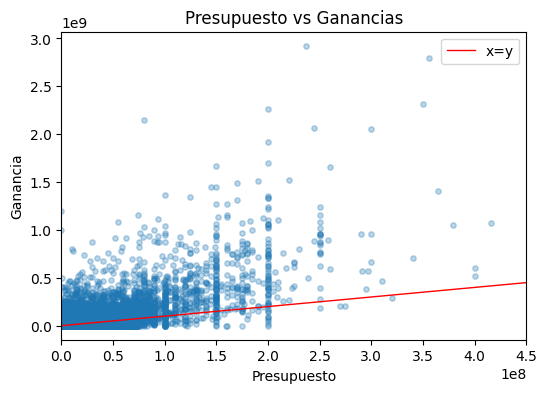

In [ ]:
# Presupuesto vs Ganancia
x = np.linspace(0, 450000000, 100)
y = x

plt.figure(figsize=(6,4))
plt.plot(x, y, color='red', linewidth=1, label='x=y')
plt.scatter(df2['budget'], df2['revenue'], s=15, alpha=0.3)
plt.title('Presupuesto vs Ganancias')
plt.xlabel('Presupuesto')
plt.ylabel('Ganancia')
plt.xlim(0, 450000000)
plt.legend(loc='best')
plt.show()

In [ ]:
# Top 20 compañías productoras -> budget
temp_df = pd.DataFrame({'production_company_names': df2['production_company_names'], 'budget': df2['budget']})
top_production_companies_budget = temp_df.groupby('production_company_names')['budget'].mean().sort_values(ascending=False)
display(top_production_companies_budget.head(20))

,budget
production_company_names,
"['20th Century Studios', 'Lightstorm Entertainment', 'TSG Entertainment']",4.000000e+08
"['Walt Disney Pictures', 'Jerry Bruckheimer Films', 'Moving Picture Company']",3.790000e+08
"['20th Century Studios', 'Lightstorm Entertainment']",3.500000e+08
"['Universal Pictures', 'Original Film', 'One Race', 'Perfect Storm Entertainment']",3.400000e+08
"['Lucasfilm Ltd.', 'Bad Robot']",3.305000e+08
"['AGBO', 'Skybound Entertainment']",3.200000e+08
"['Paramount Pictures', 'Scott Free Productions', 'Lucy Fisher/Douglas Wick Productions']",3.100000e+08
"['Jerry Bruckheimer Films', 'Second Mate Productions', 'Walt Disney Pictures']",3.000000e+08
"['RatPac Entertainment', 'Cruel & Unusual Films', 'Atlas Entertainment', 'Warner Bros. Pictures', 'DC Films']",3.000000e+08


### **Conclusiones**

Podemos observar que ambos conjuntos varían en cuestión a la calidad de los datos. Además, notamos que ambos conjuntos comparten campos o tienen campos similares.

Sin embargo, en ambos conjuntos de datos alguna variable tiene información más completa, un mejor formato o  simplemente tiene menos valores faltantes, por lo que vamos a unir ambos conjuntos y nos vamos a quedar solamente con las columnas que más nos interesan.

Después del preprocesamiento nuestro dataset va a tener las siguientes variables:

**Title, Rating, Genres, Plot Keywords, Director, Cast, Writer, Language, Country, Release Date, Production Company, Budget, Revenue y Runtime.**

## Primer Preprocesamiento

In [ ]:
# Vamos a quitar las columnas que no nos interesan de cada uno de ellos
df1 = df1.drop(columns=['Run Time','User Rating','path','year'],
               errors='ignore')
df2 = df2.drop(columns=['id','adult','genre_names','popularity',
                        'vote_average','vote_count'],
               errors='ignore')

In [ ]:
# Queremos unir ambos conjuntos de datos por el título de la película.
# Para esto vamos a limpiar las cadenas de los títulos en df1 y df2.
import string

# Función auxiliar para limpiar cadenas:
def limpiar_cad(cad):
  if cad is None:
    return None
  cad = str(cad).lower()
  spec_chars = str.maketrans('', '', string.punctuation + '¡¿')
  cad = cad.translate(spec_chars)
  return cad

In [ ]:
# Limpiamos los títulos
df1['movie title'] = df1['movie title'].apply(limpiar_cad)
df2['title'] = df2['title'].apply(limpiar_cad)

In [ ]:
# Unimos df1 y df2 con .merge() por título
df = pd.merge(df1, df2, left_on='movie title', right_on='title')
df = df.drop(columns=['title'], errors='ignore')

In [ ]:
# Quitamos duplicados y filas con registros vacíos ('[]')
df = df.drop_duplicates(subset=['movie title'])
df = df[df['origin_country'] != '[]']
df = df[df['production_company_names'] != '[]']

In [ ]:
# Tamaño del conjunto y número de registros faltantes
print('Tamaño del conjunto de datos final:',df.shape)
print('\nDatos faltantes:\n')
print(df.isna().sum())

Tamaño del conjunto de datos final: (18685, 15)

Datos faltantes:

movie title                  0
Rating                       0
Generes                      0
Overview                    86
Plot Kyeword                 0
Director                     0
Top 5 Casts                  0
Writer                       0
original_language            0
origin_country               0
release_date                 0
production_company_names     0
budget                       0
revenue                      0
runtime                      0
dtype: int64


Como podemos ver, nos faltan 86 overviews. Fuera de esta variable, los datos están completos.

In [ ]:
# Renombramos los campos
df = df.rename(columns={
                        'movie title': 'Title',
                        'Generes': 'Genres',
                        'Top 5 Casts' : 'Cast',
                        'Plot Kyeword' : 'Keywords',
                        'original_language' : 'Language',
                        'origin_country': 'Country',
                        'release_date' : 'Release Date',
                        'production_company_names': 'Production Company',
                        'budget' : 'Budget',
                        'revenue' : 'Revenue',
                        'runtime' : 'Runtime'})

In [ ]:
# Limpiamos las cadenas de las columnas que faltan (Director y Writer)
limpiar = ['Director','Writer']
for col in limpiar:
  df[col] = df[col].apply(limpiar_cad)

# Aplicamos minúsculas en las columnas Language y Overview
df['Language'] = df['Language'].str.lower()
df['Overview'] = df['Overview'].str.lower()

In [ ]:
# Para algunas columnas necesitamos que los elementos separados por comas estén en una lista
# Para ello utilizaremos la función .literal_eval() del módulo ast
import ast

# Convertimos los strings de las columnas en listas
tolist = ['Genres','Cast','Production Company','Country', 'Keywords']
for col in tolist:
  df[col] = df[col].apply(ast.literal_eval)

In [ ]:
# Aplicamos limpiar_cad a cada elemento de estas nuevas listas

# Función auxiliar para limpiar elementos de listas
# Utilizando la función limpiar_cad anterior
def limpiar_elem(L):
  lista = [limpiar_cad(item) for item in L]
  return lista

limpiar2 = ['Genres','Cast','Production Company','Country', 'Keywords']
for col in limpiar2:
  df[col] = df[col].apply(limpiar_elem)

In [ ]:
# Convertimos la fecha a tipo 'datetime'
df['Release Date'] = pd.to_datetime(df['Release Date'], errors='coerce')

In [ ]:
# Redondeamos los presupuestos y ganancias en millones de dólares.
# (Antes estaban en dólares)
df['Budget'] = (df['Budget'] / 1000000).round(2)
df['Revenue'] = (df['Revenue'] / 1000000).round(2)

In [ ]:
# Muestra del conjunto de datos ya limpio
df.head(3)

,Title,Rating,Genres,Overview,Keywords,Director,Cast,Writer,Language,Country,Release Date,Production Company,Budget,Revenue,Runtime
0,top gun maverick,8.6,"[action, drama]",after more than thirty years of service as one...,"[fighter jet, sequel, us navy, fighter aircraf...",joseph kosinski,"[jack epps jr, peter craig, tom cruise, jennif...",jim cash,en,[us],2022-05-21,"[skydance media, don simpsonjerry bruckheimer ...",170.00,1488.73,131
1,jurassic world dominion,6,"[action, adventure, scifi]",four years after the destruction of isla nubla...,"[dinosaur, jurassic park, tyrannosaurus rex, v...",colin trevorrow,"[colin trevorrow, derek connolly, chris pratt,...",emily carmichael,en,[us],2022-06-01,"[amblin entertainment, universal pictures]",583.90,1004.00,147
6,spiderhead,5.4,"[action, crime, drama]","in the near future, convicts are offered the c...","[discover, medical, test, reality, fictional d...",joseph kosinski,"[rhett reese, paul wernick, chris hemsworth, m...",george saunders,en,[us],2022-06-17,"[grand electric, the new yorker studios]",26.72,48.06,107


In [ ]:
# Finalmente, exportamos el dataframe limpio como csv
# Vamos a usar este para todo el análisis subsecuente
df.to_csv('movies_limpio.csv', index=False)

## **Modelos aplicados para el análisis de los datos**

##**1.Modelo de Regresión: Predecir las ganancias de una película**

### Objetivo

Buscamos predecir las ganancias netas de una película a partir de algunas características de nuestro conjunto de datos. Estas son:

* Presupuesto
* Duración
* Fecha de lanzamiento (nos interesa el mes)
* Género
* Rating
* Idioma (nos interesa saber si está en inglés)
* Compañía productora (nos interesa saber si pertenece al top de compañías productoras)
* País de origen

Vamos a crear dos nuevas variables:

1. Profit: Mide ganancia - el presupuesto.
2. Profit Scaled : Escala profit.

Profit Scaled será nuestra variable objetivo (**y**).

### Preprocesamiento

In [ ]:
# Importamos el dataset
df = pd.read_csv('movies_limpio.csv')

In [ ]:
# Creamos las 2 nuevas columnas
from sklearn.preprocessing import StandardScaler
sc_profit = StandardScaler()

df['Profit'] = df['Revenue'] - df['Budget']
df['Profit Scaled'] = sc_profit.fit_transform(df[['Profit']])

In [ ]:
# Separamos nuestros datos en variables predictoras 'X' y variables objetivo 'y'
X = df[['Budget', 'Runtime', 'Release Date', 'Genres', 'Language', 'Production Company', 'Rating', 'Country']]
y = df[['Profit', 'Profit Scaled']]

In [ ]:
# Convertimos 'Release Date' a tipo 'datetime' en X
# Extraemos el mes de 'Release Date'
# Llenamos posibles huecos en Month
X['Release Date'] = pd.to_datetime(X['Release Date'], errors='coerce')
X['Month'] = X['Release Date'].dt.month
X = X.drop(columns=['Release Date'], errors='ignore')
X['Month'] = X['Month'].fillna(X['Month'].median())

In [ ]:
# Convertimos la lista de géneros en columnas individuales
# Creamos las variables dummy (una columna por género)
import ast

X['Genres'] = X['Genres'].apply(ast.literal_eval)
X['Genres_Clean'] = X['Genres'].apply(lambda x: ', '.join(x))
genres_dummies = X['Genres_Clean'].str.get_dummies(sep=', ')

# Incluimos los géneros dummy en X
# Eliminamos las columnas originales de géneros
X = pd.concat([X, genres_dummies], axis=1)
X = X.drop(columns=['Genres', 'Genres_Clean'], errors='ignore')

In [ ]:
# Como son demasiados países, nos conviene considerar el top 10
# y los demás los agruparemos en una categoría 'Country_OTHER'

import ast

X['Country_List'] = X['Country'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else [])
paises = [pais for sublista in X['Country_List'] for pais in sublista]
top10_paises = pd.Series(paises).value_counts().head(10).index.tolist()

# Convertimos la lista de top 10 países en columnas individuales
for pais in top10_paises:
  X[f'Country_{pais}'] = X['Country_List'].apply(lambda x: 1 if pais in x else 0)

# Creamos la variable 'Other' con ayuda de una función auxiliar
def es_otro(lista_paises):
    if len(lista_paises) > 0 and set(lista_paises).isdisjoint(top10_paises):
        return 1
    return 0

X['Country_OTHER'] = X['Country_List'].apply(es_otro)

# Eliminamos la columnas de países originales
X = X.drop(columns=['Country', 'Country_List'], errors='ignore')

In [ ]:
# Creamos la variable 'In Top Company' que nos dice si la película pertenece
# al top de compañías productoras
# Eliminamos la columna original de Production Company

# Función auxiliar para verificar si alguna compañía está en la lista 'top'
def is_top_company(companies):
    for company in companies:
        if company in top_companies:
            return True
    return False

import ast

top_companies = ['20th century studios', 'walt disney pictures', 'universal pictures',
                 'lucasfilm ltd', 'paramount pictures', 'warner bros pictures',
                 'marvel studios', 'columbia pictures', 'metrogoldwynmayer',
                 'tsg entertainment', 'apple studios', 'monolith pictures',
                 'amazon mgm studios', 'new line cinema', 'lionsgate',
                 'dreamworks pictures', 'miramax', 'united artists']

X['Top Company'] = X['Production Company'].apply(is_top_company).astype(int)
X = X.drop(columns=['Production Company'], errors='ignore')

In [ ]:
# Creamos la variable 'In English' que nos dice si la película está o no en inglés
# Eliminamos la columna original de idiomas
X['In English'] = (X['Language'] == 'en').astype(int)
X = X.drop(columns=['Language'], errors='ignore')

In [ ]:
# Convertimos los datos de la columna 'Rating' a numeric
# Llenamos posibles huecos
X['Rating'] = X['Rating'].apply(pd.to_numeric, errors='coerce')
X['Rating'] = X['Rating'].fillna(X['Rating'].median())

In [ ]:
# Estandarizamos las variables numéricas de X
sc = StandardScaler()
X[['Budget', 'Runtime', 'Month', 'Rating']] = sc.fit_transform(X[['Budget', 'Runtime', 'Month', 'Rating']])

In [ ]:
# Visualización de 'X' y 'y'
display(X.head(3))
display(y.head(3))

,Budget,Runtime,Rating,Month,action,adventure,animation,biography,comedy,crime,...,Country_ca,Country_fr,Country_au,Country_de,Country_jp,Country_it,Country_su,Country_OTHER,Top Company,In English
0,5.820443,1.078776,2.179823,-0.484311,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,21.259820,1.572607,0.023401,-0.196308,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,0.475785,0.338030,-0.474234,-0.196308,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1


,Profit,Profit Scaled
0,1318.73,16.371169
1,420.10,5.083489
2,21.34,0.074670


### Aplicación de PCA (Reducción de Características)

Como el conjunto de variables predictoras contiene 39 características, vamos a aplicar PCA al conjunto de datos para después realizar un análisis de varianza acumulada comparando una cantidad distinta de componentes.

Esto con la finalidad de ver si nos conviene quedarnos con todas las características o si es mejor reducir la dimensionalidad de nuestro conjunto de datos.

In [ ]:
# Bibliotecas necesarias
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [ ]:
# Prueba de PCA
pca_test = PCA()
pca_test.fit(X)

# Calculamos la varianza acumulada para decidir la cantidad de características a reducir
varianza_acumulada = np.cumsum(pca_test.explained_variance_ratio_)

print("Varianza acumulada: ")
for i, varianza in enumerate(varianza_acumulada):
    print(f"{i + 1} componentes: {varianza:.4f} de la varianza.")

Varianza acumulada: 
1 componentes: 0.2062 de la varianza.
2 componentes: 0.3660 de la varianza.
3 componentes: 0.5148 de la varianza.
4 componentes: 0.6272 de la varianza.
5 componentes: 0.6808 de la varianza.
6 componentes: 0.7227 de la varianza.
7 componentes: 0.7588 de la varianza.
8 componentes: 0.7898 de la varianza.
9 componentes: 0.8189 de la varianza.
10 componentes: 0.8397 de la varianza.
11 componentes: 0.8577 de la varianza.
12 componentes: 0.8751 de la varianza.
13 componentes: 0.8907 de la varianza.
14 componentes: 0.9022 de la varianza.
15 componentes: 0.9123 de la varianza.
16 componentes: 0.9222 de la varianza.
17 componentes: 0.9311 de la varianza.
18 componentes: 0.9390 de la varianza.
19 componentes: 0.9451 de la varianza.
20 componentes: 0.9512 de la varianza.
21 componentes: 0.9567 de la varianza.
22 componentes: 0.9616 de la varianza.
23 componentes: 0.9657 de la varianza.
24 componentes: 0.9696 de la varianza.
25 componentes: 0.9735 de la varianza.
26 componente

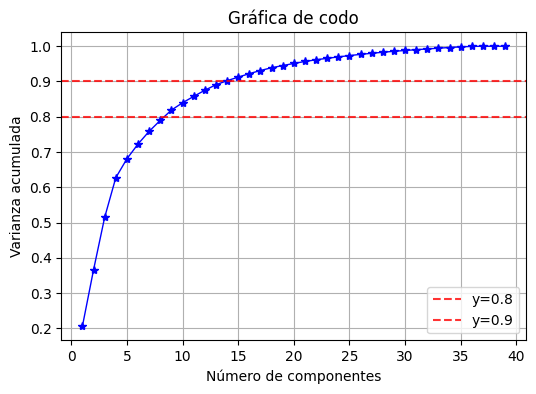

In [ ]:
# Gráfica de codo
plt.figure(figsize=(6, 4))
plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, marker='*', linestyle='-', color='b', lw=1)
plt.axhline(y=0.8, color='red', linestyle='--', label='y=0.8', alpha=0.8)
plt.axhline(y=0.9, color='red', linestyle='--', label='y=0.9', alpha=0.8)
plt.xlabel('Número de componentes')
plt.ylabel('Varianza acumulada')
plt.title('Gráfica de codo')
plt.grid(True)
plt.legend(loc='best')
plt.show()

Podríamos quedarnos con 9 características (81% de la información) o con 14 características (90% de la información).

Sin embargo, al evaluar la regresión lineal con y sin PCA, nos dimos cuenta que el modelo era más preciso sin PCA. Esto debido a que tenemos muchas columnas con 1s y 0s.

### 1er Modelo: Regresión Lineal

Haremos regresión lineal sobre la columna de ganancias para predecir las ganancias de una película con base en las características estabecidas en X.

In [ ]:
# Bibliotecas necesarias
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [ ]:
# Separación de datos (Prueba / Entrenamiento)

# Variable objetivo
y_model = y['Profit Scaled']

X_train, X_test, y_train, y_test = train_test_split(X, y_model, test_size=0.2, random_state=42)

# Aplicación del modelo
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Evaluación del modelo
r2_lr = r2_score(y_test, y_pred_lr)
rmse_lr = root_mean_squared_error(y_test, y_pred_lr)

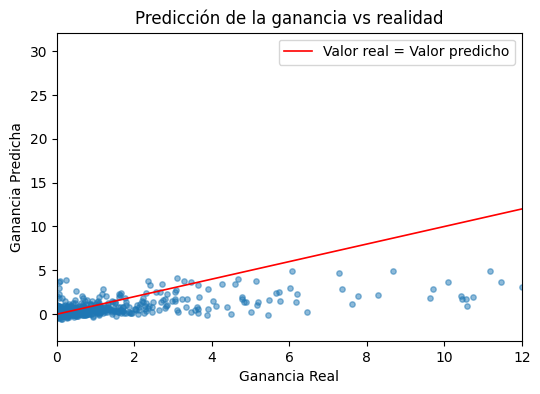

In [ ]:
# Visualización: Predicción vs Realidad
plt.figure(figsize=(6, 4))
plt.scatter(x=y_test.values.flatten(), y=y_pred_lr.flatten(), alpha=0.5, s=15)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], label='Valor real = Valor predicho', c='r', lw=1.2)
plt.xlabel('Ganancia Real')
plt.ylabel('Ganancia Predicha')
plt.title(f'Predicción de la ganancia vs realidad')
plt.xlim(0, 12)
plt.legend(loc='best')
plt.show()

In [ ]:
# Precisión del modelo
print(f"R^2 Score: {r2_lr:.2f}")
print(f"Raíz del error cuadrático medio: {rmse_lr:.2f}")

R^2 Score: 0.38
Raíz del error cuadrático medio: 0.97


Como podemos observar, la calidad del modelo de regresión lineal fue baja, con un R^2 score de 0.38 y un RMSE de 0.97. Sin embargo, podemos intentar con otros modelos para comparar su desempeño.

### 2do modelo: Random Forest

Vamos a aplicar el algoritmo 'Random Forest' con 100 árboles para ver si puede predecir las ganancias con las características de 'X'.

In [ ]:
# Bibliotecas necesarias
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [ ]:
# Aplicación del modelo
# Con 100 árboles de decisión
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# Evaluación del modelo
r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = root_mean_squared_error(y_test, y_pred_rf)

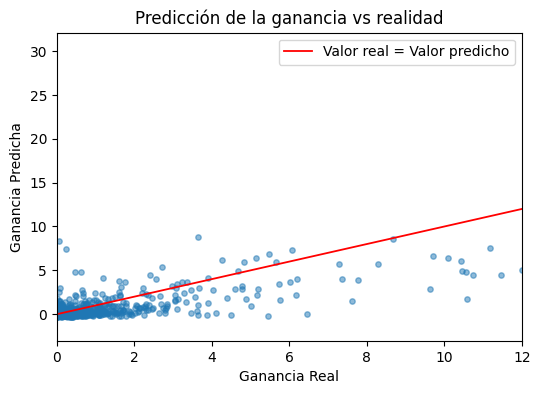

In [ ]:
# Visualización: Predicción vs Realidad
plt.figure(figsize=(6, 4))
plt.scatter(x=y_test.values.flatten(), y=y_pred_rf.flatten(), alpha=0.5, s=15)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], label='Valor real = Valor predicho', c='r', lw=1.3)
plt.xlabel('Ganancia Real')
plt.ylabel('Ganancia Predicha')
plt.title(f'Predicción de la ganancia vs realidad')
plt.xlim(0,12)
plt.legend(loc='best')
plt.show()

In [ ]:
# Precisión del modelo
print(f"R^2 Score: {r2_rf:.2f}")
print(f"Raíz del error cuadrático medio: {rmse_rf:.2f}")

R^2 Score: 0.55
Raíz del error cuadrático medio: 0.82


Este modelo mejoró a comparación a la regresión lineal, con un score de 0.55 y un RMSE de 0.82.

### 3er Modelo: XGBoost

In [ ]:
# Bibliotecas Necesarias
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, r2_score
import matplotlib.pyplot as plt
import xgboost as xgb

In [ ]:
# Aplicación del modelo
model = xgb.XGBRegressor( n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
model.fit(X_train, y_train)
y_pred_xgb = model.predict(X_test)

# Evaluación del modelo
r2_xgb = r2_score(y_test, y_pred_xgb)
rmse_xgb = root_mean_squared_error(y_test, y_pred_xgb)

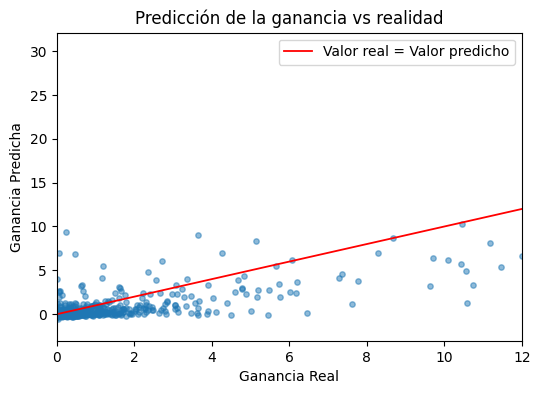

In [ ]:
# Visualización: Predicción vs Realidad
plt.figure(figsize=(6, 4))
plt.scatter(x=y_test.values.flatten(), y=y_pred_xgb.flatten(), alpha=0.5, s=15)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], label='Valor real = Valor predicho', c='r', lw=1.3)
plt.xlabel('Ganancia Real')
plt.ylabel('Ganancia Predicha')
plt.title(f'Predicción de la ganancia vs realidad')
plt.xlim(0,12)
plt.legend(loc='best')
plt.show()

In [ ]:
# Precisión del modelo
print(f"R^2 Score: {r2_xgb:.2f}")
print(f"Raíz del error cuadrático medio: {rmse_xgb:.2f}")

R^2 Score: 0.54
Raíz del error cuadrático medio: 0.84


La regresión por XGBoost es comparable a Random Forest. Sin embargo, no fue mejor que este.

### 4to Modelo: Regresión Polinomial con Ridge

Finalmente, vamos a probar el modelo de regresión polinomial con regularización Ridge.

Aplicamos regresión polinomial para capturar las relaciones entre variables (como la interacción entre el presupuesto y el género). Como esto genera muchas nuevas variables, utilizamos la regularización Ridge para evitar el sobreajuste.


In [ ]:
# Bibliotecas necesarias
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, root_mean_squared_error
import matplotlib.pyplot as plt

In [ ]:
# Aplicación de modelos

# Regresión polinomial
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Ridge
ridge = Ridge(alpha=10)
ridge.fit(X_train_poly, y_train)
y_pred_rid = ridge.predict(X_test_poly)

# Evaluación del modelo
r2_rid = r2_score(y_test, y_pred_rid)
rmse_rid = root_mean_squared_error(y_test, y_pred_rid)

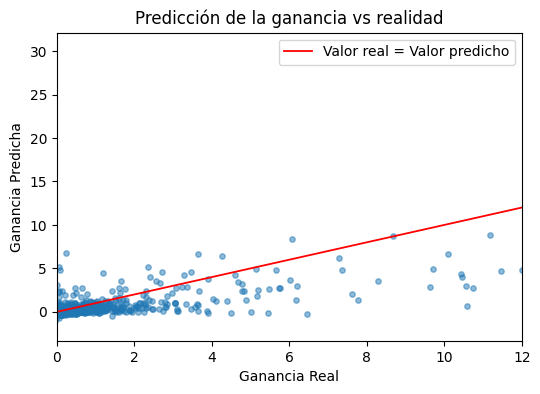

In [ ]:
# Visualización: Predicción vs Realidad
plt.figure(figsize=(6, 4))
plt.scatter(x=y_test.values.flatten(), y=y_pred_rid.flatten(), alpha=0.5, s=15)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], label='Valor real = Valor predicho', c='r', lw=1.3)
plt.xlabel('Ganancia Real')
plt.ylabel('Ganancia Predicha')
plt.title(f'Predicción de la ganancia vs realidad')
plt.xlim(0,12)
plt.legend(loc='best')
plt.show()

In [ ]:
# Precisión del modelo
print(f"R^2 Score: {r2_rid:.2f}")
print(f"Error cuadrático medio: {rmse_rid:.2f}")

R^2 Score: 0.57
Error cuadrático medio: 0.81


Este modelo logró ser el más preciso, con un R^2 score de 0.57 y un RMSE de 0.81.

### Evaluación de Predicciones

Para evaluar las predicciones debemos 're-escalar' los valores predichos para que estos estén expresados en millones de dólares.

In [ ]:
# Invertimos las predicciones del modelo y los valores reales
y_pred_mmd = sc_profit.inverse_transform(y_pred_rid.reshape(-1, 1))
y_test_mmd = sc_profit.inverse_transform(y_test.values.reshape(-1, 1))

# Evaluación de las predicciones (mmd)
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test_mmd, y_pred_mmd)
print(f"Error Promedio (millones de dólares): {mae:,.2f}.")

Error Promedio (millones de dólares): 22.95.


Podemos observar que el modelo tiene un margen de error de aproximadamente 23 millones de dólares.

Esto puede ser muy malo para películas de bajo presupuesto, o insignificante para películas con un presupuesto masivo.

##**2. Modelo de Clasificación: Predecir si será un éxito**

### Objetivo

Buscamos poder clasificar las películas de nuestro conjunto de datos en dos categorías:

* Rentables
* No Rentables

Vamos a definir la variable objetivo 'EsRentable' como aquellas películas que duplican sus ganancias en relación a su presupuesto.

Las rentables las agrupamos con un 1 y las no rentables con un 0.

###Importación de bibliotecas

In [ ]:
# Bibliotecas necesarias
import ast
from sklearn.model_selection import train_test_split

#Importar el modelo RandomForest
from sklearn.ensemble import RandomForestClassifier

# Importar el modelo XGBoost
from xgboost import XGBClassifier

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.feature_extraction.text import CountVectorizer

import warnings
warnings.filterwarnings('ignore')

###Preprocesamiento

In [ ]:
# Función Auxiliar para Procesar Listas

def safe_literal_eval(s):
    """Convierte de forma segura un string que parece lista a una lista real."""
    try:
        if isinstance(s, list): return s
        if isinstance(s, str) and s.startswith('[') and s.endswith(']'):
            return ast.literal_eval(s)
        return [s] if isinstance(s, str) else []
    except (ValueError, SyntaxError, TypeError):
        return []


In [ ]:
# Función para Obtener Características (Top N)

def create_top_n_features(df, column_name, top_n=20):
    """
    Toma una columna con listas (ej. 'Genres'), encuentra los 'top_n' items
    más frecuentes y crea una columna binaria (0/1) para cada uno.
    """
    print(f"Procesando Top {top_n} características para: {column_name}")

    col_lists = df[column_name].apply(safe_literal_eval)
    all_items = col_lists.explode()
    all_items = all_items.dropna()[all_items != '']
    top_items = all_items.value_counts().head(top_n).index.tolist()
    new_cols = []
    for item in top_items:
        new_col_name = f"{column_name}_{item}".replace(' ', '_').replace("'", "").replace('"', '').replace('.', '')
        new_cols.append(new_col_name)
        df[new_col_name] = col_lists.apply(lambda x: 1 if item in x else 0)
    return df, new_cols

In [ ]:
# Carga y Preparación de Datos (movies_limpio.csv)
try:
    df = pd.read_csv('movies_limpio.csv')
except FileNotFoundError:
    print("Error: El archivo 'movies_limpio.csv' no se encontró.")

df = df[df['Budget'] > 0].copy()
df['Keywords'] = df['Keywords'].fillna("[]")
df['Genres'] = df['Genres'].fillna("[]")
df['Cast'] = df['Cast'].fillna("[]")
df['Director'] = df['Director'].fillna("")
df['Production Company'] = df['Production Company'].fillna("[]")

In [ ]:
# Variable Objetivo (y = 'EsRentable')

df['EsRentable'] = np.where(df['Revenue'] > (df['Budget'] * 2), 1, 0)
class_balance = df['EsRentable'].value_counts(normalize=True)
class_balance

,proportion
EsRentable,
0,0.62949
1,0.37051


In [ ]:
# Ingeniería de Características (X) -- (características numéricas y categóricas iguales)

df['Budget_log'] = np.log1p(df['Budget'])
df['Release Date'] = pd.to_datetime(df['Release Date'], errors='coerce')
df['Release_Year'] = df['Release Date'].dt.year
df['Release_Month'] = df['Release Date'].dt.month
df['Runtime'] = df['Runtime'].fillna(df['Runtime'].median())
df['Release_Year'] = df['Release_Year'].fillna(df['Release_Year'].median())
df['Release_Month'] = df['Release_Month'].fillna(df['Release_Month'].median())

df, genre_cols = create_top_n_features(df, 'Genres', top_n=15)
df, cast_cols = create_top_n_features(df, 'Cast', top_n=50)
df, director_cols = create_top_n_features(df, 'Director', top_n=30)
df, company_cols = create_top_n_features(df, 'Production Company', top_n=20)

Procesando Top 15 características para: Genres
Procesando Top 50 características para: Cast
Procesando Top 30 características para: Director
Procesando Top 20 características para: Production Company


In [ ]:
# Usamos CountVectorizer para preprocesar las keywords
def preprocess_keywords(s):
    return ' '.join(safe_literal_eval(s))

df['Keywords_text'] = df['Keywords'].apply(preprocess_keywords)

count_vectorizer = CountVectorizer(max_features=150, stop_words='english')

# Creamos la matriz de conteo
count_matrix = count_vectorizer.fit_transform(df['Keywords_text'])

# Nombres de las nuevas columnas
keyword_cols = [f"KW_{name}" for name in count_vectorizer.get_feature_names_out()]

# Creamos el DataFrame de conteo
count_df = pd.DataFrame(
    count_matrix.toarray(), # .toarray() es necesario
    columns=keyword_cols,
    index=df.index
)

###1er modelo: Random Forest

In [ ]:
# Definimos X (Características)
base_features = ['Budget_log', 'Runtime', 'Release_Year', 'Release_Month']
categorical_features = genre_cols + cast_cols + director_cols + company_cols

X_base = df[base_features + categorical_features]
# ¡Combinamos con el nuevo 'count_df'!
X = pd.concat([X_base, count_df], axis=1)

# Definimos y -> (Objetivo)
y = df['EsRentable']
X = X.fillna(0)

In [ ]:
# Dividir Datos (Entrenamiento y Prueba)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)
print(f"Datos divididos: {len(X_train)} para entrenar, {len(X_test)} para probar.")

Datos divididos: 13489 para entrenar, 4497 para probar.


In [ ]:
# Crear y Entrenar el Modelo (RandomForest - 100 árboles de decisión)
model_clf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

print("\nEntrenando el modelo RandomForestClassifier.")
model_clf.fit(X_train, y_train)


Entrenando el modelo RandomForestClassifier.


RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)

In [ ]:
# Evaluación del Modelo
print("\nEvaluación del Modelo de Clasificación")
y_pred = model_clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

cm = confusion_matrix(y_test, y_pred)

print(f"Accuracy (Precisión General): {accuracy:.2%}")


Evaluación del Modelo de Clasificación
Accuracy (Precisión General): 80.59%


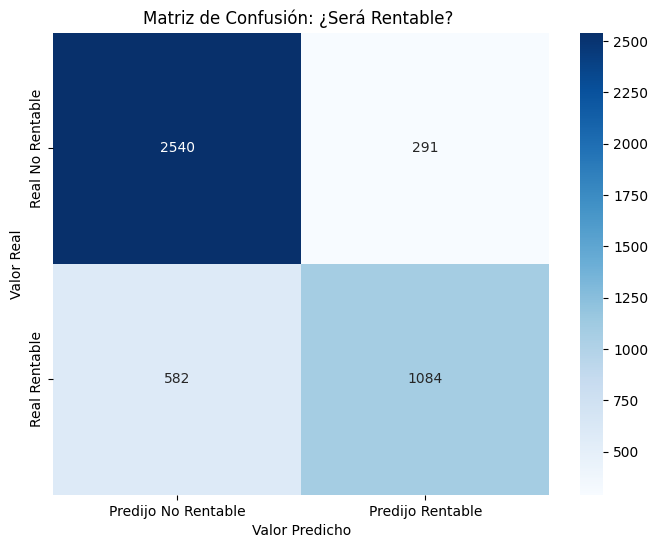

In [ ]:
# Visualización de la Matriz de Confusión
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predijo No Rentable', 'Predijo Rentable'],
            yticklabels=['Real No Rentable', 'Real Rentable'])
plt.title('Matriz de Confusión: ¿Será Rentable? ')
plt.ylabel('Valor Real')
plt.xlabel('Valor Predicho')
plt.show()

Podemos observar que Random Forest predijo 2540 de 2831 películas no rentables (aprox. 89%) mientras que predijo 1084 de 1666 (aprox. 65%) de las películas que son rentables.

###2nd modelo: XGBOOST

In [ ]:
# Definir X (Características), y (Objetivo)

base_features = ['Budget_log', 'Runtime', 'Release_Year', 'Release_Month']
categorical_features = genre_cols + cast_cols + director_cols + company_cols
X_base = df[base_features + categorical_features]

X = pd.concat([X_base, count_df], axis=1)
y = df['EsRentable']
X = X.fillna(0)


In [ ]:
# Dividir Datos (Entrenamiento y Prueba)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"Datos divididos: {len(X_train)} para entrenar, {len(X_test)} para probar.")

Datos divididos: 13489 para entrenar, 4497 para probar.


In [ ]:
# Crear y Entrenar el Modelo
count_0 = class_balance[0]
count_1 = class_balance[1]
scale_pos_weight = count_0 / count_1
print(f"\nUsando 'scale_pos_weight' de: {scale_pos_weight:.2f} para manejar desbalance.")

model_xgb = XGBClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight,
    early_stopping_rounds=10,
    eval_metric='logloss'
)

print("\nEntrenando el modelo XGBClassifier")
model_xgb.fit(X_train, y_train,
              eval_set=[(X_test, y_test)],
              verbose=False)


Usando 'scale_pos_weight' de: 1.70 para manejar desbalance.

Entrenando el modelo XGBClassifier


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=10,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=-1,
              num_parallel_tree=None, ...)

In [ ]:
# Evaluación del Modelo
print("\n--- Evaluación del Modelo (XGBoost)")
y_pred = model_xgb.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy (Precisión General): {accuracy:.2%}")


--- Evaluación del Modelo (XGBoost)
Accuracy (Precisión General): 80.90%


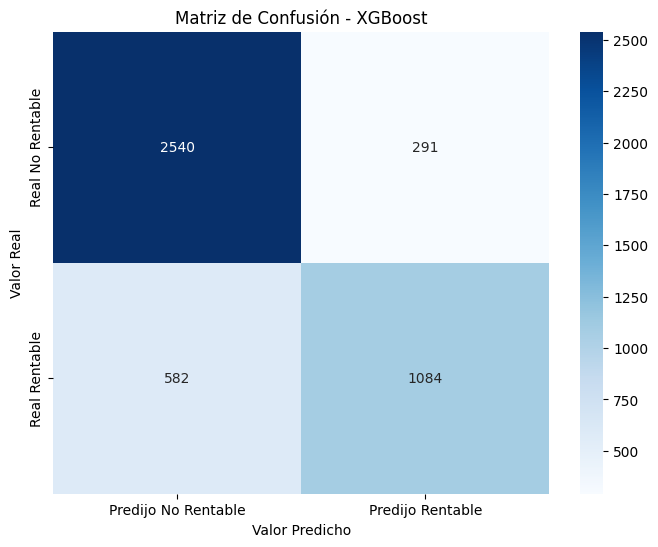

In [ ]:
# Visualización de la Matriz de Confusión
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predijo No Rentable', 'Predijo Rentable'],
            yticklabels=['Real No Rentable', 'Real Rentable'])


plt.title('Matriz de Confusión - XGBoost')
plt.ylabel('Valor Real')
plt.xlabel('Valor Predicho')
plt.show()

XGBoost predijo la misma proporción de películas rentables y no rentables. Sin embargo, la variable 'accuracy' nos dice que este fue marginalmente más preciso.

### Conclusiones

Como podemos observar, ambos modelos fueron comparables en su capacidad para clasificar éxitos y fracasos (alrededor del 80%).

Sin embargo, tiene una mayor precisión para predecir fracasos. Esto se debe, en parte, a la mayor proporción de fracasos en el conjunto (tiene más datos para aprender).

##**3. Recomendador de películas**

### Objetivo

Buscamos programar un recomendador de películas basándonos en las siguientes características:

* Los géneros
* Las palabras clave
* El cast y el director

Consideramos que el algoritmo 'k neirest neighbors' o 'k-vecinos' funciona mejor para realizar esta tarea.

### Preprocesamiento

Para los géneros vamos a generar columnas 'dummy'. Además, vamos a crear una 'sopa de palabras' con todos los campos para utilizar en el CountVectorizer de sklearn (top palabras más comunes para no tener tantas columnas).

In [ ]:
# Importamos el dataset
df = pd.read_csv('movies_limpio.csv')
df['Rating'] = df['Rating'].apply(pd.to_numeric, errors='coerce')

In [ ]:
# Separamos los datos
X = df[['Genres', 'Keywords', 'Director', 'Cast']].copy()

In [ ]:
# Quitamos espacios en los strings de directores
X['Director'] = X['Director'].apply(lambda x: x.replace(" ", "").lower())

In [ ]:
# Función auxiliar para crear sopa de palabras en una columna
import ast
def sopa(x):
  try:
    # 1. Si es string, lo convertimos a lista real
    if isinstance(x, str):
      x = ast.literal_eval(x)

    # 2. Si ya es lista, limpiamos
    if isinstance(x, list):
      return " ".join([i.replace(" ", "").lower() for i in x])

    return ""
  except:
    return ""

In [ ]:
# Aplicamos la función al cast, géneros y las keywords
# Borramos las columnas originales
X['Cast Soup'] = X['Cast'].apply(sopa)
X['Genres Soup'] = X['Genres'].apply(sopa)
X['Keywords Soup'] = X['Keywords'].apply(sopa)
X = X.drop(columns=['Cast', 'Keywords'], errors='ignore')

In [ ]:
# Ahora sí, creamos la 'sopa de palabras'
X['soup'] = (X['Director'] + ' ' +
             X['Genres Soup'] + ' ' +
             X['Cast Soup'] + ' ' +
             X['Keywords Soup'])

In [ ]:
# Agregamos las columnas dummy de Genres y borramos las que no son dummies
import ast
X['Genres'] = X['Genres'].apply(ast.literal_eval)
X['Genres_Clean'] = X['Genres'].apply(lambda x: ', '.join(x))
genres_dummies = X['Genres_Clean'].str.get_dummies(sep=', ')
X = pd.concat([X, genres_dummies], axis=1)
X = X.drop(columns=['Genres', 'Genres_Clean'], errors='ignore')

In [ ]:
# Borramos las columnas que ya no nos sirven
X = X.drop(columns=['Director','Genres Soup','Cast Soup','Keywords Soup'], errors='ignore')

In [ ]:
# Visualización de X
display(X.head(3))
X.shape

,soup,action,adventure,animation,biography,comedy,crime,drama,family,fantasy,...,music,musical,mystery,realitytv,romance,scifi,sport,thriller,war,western
0,josephkosinski action drama jackeppsjr petercr...,1,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,colintrevorrow action adventure scifi colintre...,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,josephkosinski action crime drama rhettreese p...,1,0,0,0,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0


(18685, 23)

In [ ]:
# Finalmente, aplicamos el CountVectorizer
from sklearn.feature_extraction.text import CountVectorizer

# Inicializamos el CountVectorizer
# máximas features a 4978 para quedarnos al final con 5000
count = CountVectorizer(stop_words='english', max_features=4978)

# Creamos la matriz, la convertimos en dataframe
count_matrix = count.fit_transform(X['soup'])
count_df = pd.DataFrame(count_matrix.toarray(), columns=count.get_feature_names_out())

# Concatenamos y borramos la columna 'soup'
X = X.reset_index(drop=True)
count_df = count_df.reset_index(drop=True)
X = pd.concat([X, count_df], axis=1)
X = X.drop(columns=['soup'], errors='ignore')

In [ ]:
print('Tamaño de X:', X.shape)

Tamaño de X: (18685, 5000)


### Modelo elegido: KNN (K Nearest Neighbors)

Vamos a aplicar el algoritmo de k-vecinos más cercanos para obtener en una función la recomendación de las k-películas más similares.

In [ ]:
# Bibliotecas necesarias
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors

In [ ]:
# Entrenamos el modelo
knn = NearestNeighbors(metric='cosine', algorithm='brute')
knn.fit(X)

NearestNeighbors(algorithm='brute', metric='cosine')

### Función de consulta para recomendaciones

In [ ]:
def recomendador(title=None, k=5):
  '''
  recomendador.
  Busca las k-películas más similares dado el título de una película.
  ------
  params.
  title : título de la película
  k : k-vecinos más cercanos
  ------
  returns.
  recs : lista de k-películas más similares
  '''

  # Verificación: Si la película existe en la base de datos
  mask = df['Title'] == str(title).lower()
  if not mask.any():
    print(f"La película '{title}' no existe en la base de datos.")
    return None

  # Obtentemos el índice de la primera coincidencia encontrada
  idx = df[mask].index[0]
  # Obtenemos el vector de características, manteniendo las columnas para evitar la advertencia
  features = X.iloc[[idx]]

  # Calculamos los k-vecinos
  dist, indices = knn.kneighbors(features, n_neighbors=k+1)

  # Mandamos los resultados
  print('Recomendaciones:\n')

  # Iteramos sobre los candidatos hasta llenar 'k' espacios
  for i, vecino_id in enumerate(indices[0][1:], start=1):
    titulo_vecino = df.iloc[vecino_id]['Title']
    print(f"{i}. {titulo_vecino.title()}")

  print('\n')

In [ ]:
recomendador('Finding Nemo', 3)
recomendador('Pulp fiction', 3)
recomendador('Friday the 13th', 3)

Recomendaciones:

1. Finding Dory
2. Shark Tale
3. Curious George Cape Ahoy


Recomendaciones:

1. The Hateful Eight
2. Reservoir Dogs
3. Kill Bill Vol 1


Recomendaciones:

1. Murder In The Woods
2. Friday The 13Th Part 2
3. Youre Not Alone




Como podemos observar, el recomendador arroja películas similares.
Por lo tanto, el algoritmo elegido fue una buena decisión.